Sistem '42' tohumu ile kilitlendi. Sonuclar artik tekrarlanabilir!
ue_pos.shape: (16, 1, 3)
positions.shape: (16, 3)
Shape of a: (16, 1, 1, 16, 1, 24, 14)
Shape of tau: (16, 1, 16, 24)
Shape of h_freq: (16, 1, 1, 16, 1, 14, 128)
Uretilen Grid Boyutu: (1000, 2, 1, 14, 128)
w_zf.shape: (2, 16, 14, 128)
Sizinti (Null-Space basarisi): 0.0000000000
y_received boyutu: (1000, 2, 14, 128)
UE=2 | EbNo: -5 dB | BER: 0.259625
UE=2 | EbNo: -3 dB | BER: 0.208600
UE=2 | EbNo: -1 dB | BER: 0.153869
UE=2 | EbNo: 1 dB | BER: 0.099418
UE=2 | EbNo: 3 dB | BER: 0.053195
UE=2 | EbNo: 5 dB | BER: 0.021078
UE=2 | EbNo: 7 dB | BER: 0.005319
UE=2 | EbNo: 9 dB | BER: 0.000689
UE=2 | EbNo: 11 dB | BER: 0.000028
UE=2 | EbNo: 13 dB | BER: 0.000000
UE=2 | EbNo: 15 dB | BER: 0.000000
UE=2 | EbNo: 17 dB | BER: 0.000000
UE=2 | EbNo: 19 dB | BER: 0.000000
Uretilen Grid Boyutu: (1000, 4, 1, 14, 128)
w_zf.shape: (4, 16, 14, 128)
Sizinti (Null-Space basarisi): 0.0000000000
y_received boyutu: (1000, 4, 14, 128)
UE=4 | EbNo

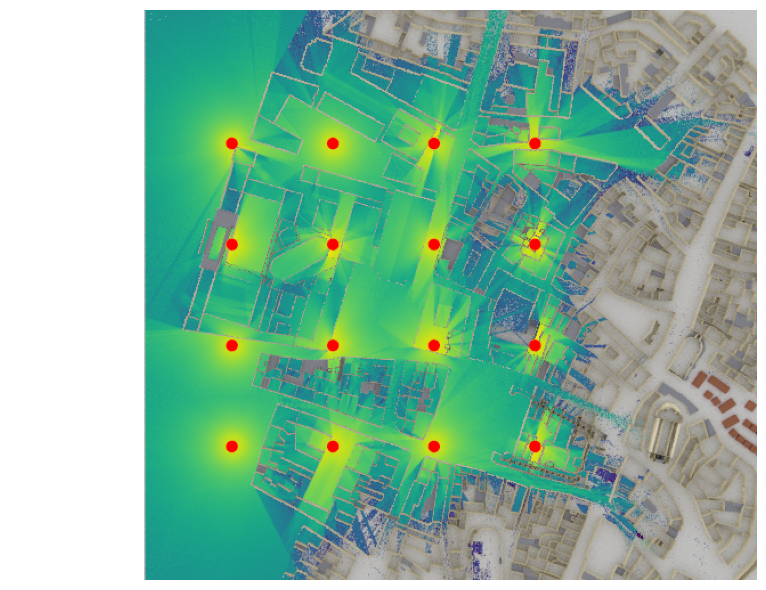

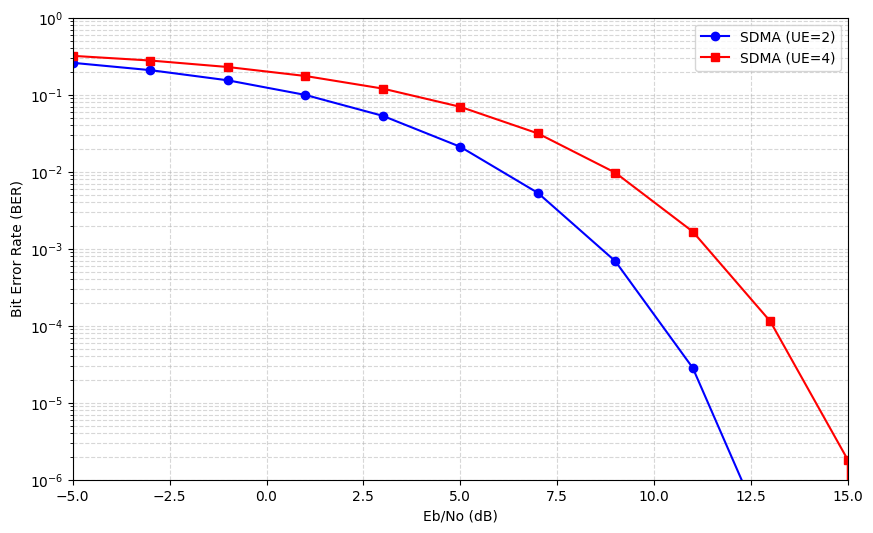

In [ ]:

# Cell-Free Massive MIMO — SDMA (ZF) Kullanici Sayisi Karsilastirmasi
# 16 AP, ZF precoding. Ayni sahnede 2 ve 4 UE icin BER performansi karsilastirilir.


import os
# GPU varsa onu kullan, yoksa "" yazilirsa CPU'ya duser; ortam degiskeni ile secilir.
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0  # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
        print("Installing Sionna and restarting the runtime. Please run the cell again.")
        os.system("pip install sionna")
        os.kill(os.getpid(), 5)
    else:
        raise e

# Tek GPU kullan ve sadece gerektigi kadar bellek ayir
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
tf.get_logger().setLevel('ERROR')

import numpy as np
import matplotlib.pyplot as plt
from sionna.phy.mapping import BinarySource, Constellation, Mapper, Demapper
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper
from sionna.phy.channel import subcarrier_frequencies, cir_to_ofdm_channel
from sionna.phy.utils import ebnodb2no, compute_ber
from sionna.rt import load_scene, Camera, Transmitter, Receiver, PlanarArray, \
                      PathSolver, RadioMapSolver

# --- Tekrarlanabilirlik icin tohum ---
my_seed = 42
np.random.seed(my_seed)
tf.random.set_seed(my_seed)
sionna.phy.config.seed = my_seed
print(f"Sistem '{my_seed}' tohumu ile kilitlendi. Sonuclar artik tekrarlanabilir!")

no_preview = True







# SISTEM PARAMETRELERI

subcarrier_spacing = 30e3   # Hz
num_time_steps = 14         # bir slottaki OFDM sembol sayisi
num_tx = 16                 # AP sayisi
num_tx_ant = 1              # her AP'de 1 anten
num_rx_ant = 1              # her UE'de 1 anten
batch_size_payload = 1000   # Monte Carlo paket sayisi
batch_size_cir = 1          # her AP icin 1 UE konumu -> toplam 16 UE konumu
fft_size = 128
num_ofdm_symbols = 14
num_bits_per_symbol = 2     # QPSK

scene = load_scene(sionna.rt.scene.munich)  #kullanılan sahne built-in münich şehridir. 

# AP'leri duzenli grid seklinde yerlestir
min_x, max_x = 0, 400
min_y, max_y = 0, 400
ap_height = 10

x_coords = np.linspace(min_x, max_x, 4)
y_coords = np.linspace(min_y, max_y, 4)

ap_positions = []
for x in x_coords:
    for y in y_coords:
        ap_positions.append([x, y, ap_height])
ap_positions = np.array(ap_positions)

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,            # yatayda kac anten -> 1 (her AP tek antenli)
                             vertical_spacing=0.5,  # elemanlar arasi mesafe (yarim dalga boyu)
                             horizontal_spacing=0.5,
                             pattern="dipole",      # dipol: 360 derece omni-yonlu patern
                             polarization="V")

for i in range(num_tx):
    if f"tx-{i}" in scene.transmitters:   # ilk calistirmada hata vermesin
        scene.remove(f"tx-{i}")
    tx = Transmitter(name=f"tx-{i}",
                     position=ap_positions[i],
                     display_radius=8.,
                     color=(1, 0, 0))
    scene.add(tx)

bird_cam = Camera(position=[200, 200, 1200], look_at=[200, 200, 0])

max_depth = 5   # radio map icin isinin maksimum yansima sayisi





# RADIO MAP

rm_solver = RadioMapSolver()
# cell_size: izgara cozunurlugu. samples_per_tx: her AP'den firlatilan isin sayisi (10 milyon).
rm = rm_solver(scene,
               max_depth=max_depth,
               cell_size=(1., 1.),
               samples_per_tx=10**7)

if no_preview:
    scene.render(camera=bird_cam, radio_map=rm, rm_vmin=-110, clip_at=12.)
else:
    scene.preview(radio_map=rm, rm_vmin=-110, clip_at=12.)






# UE POZISYONLARI

min_gain_db = -110   # bu degerin altindaki path gain'leri yok say
max_gain_db = 0
min_dist = 5         # m
max_dist = 400       # m
max_depth = 3        # path solver icin yansima sayisi

ue_pos, _ = rm.sample_positions(num_pos=batch_size_cir,  # her tx icin 1 UE -> 16 UE
                                metric="path_gain",
                                min_val_db=min_gain_db,
                                max_val_db=max_gain_db,
                                min_dist=min_dist,
                                max_dist=max_dist)
print("ue_pos.shape:", ue_pos.shape)

scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="dipole", polarization="V")

positions = np.reshape(ue_pos, [-1, 3])
print(f"positions.shape: {positions.shape}")

for i in range(len(positions)):
    rx_name = f"rx-{i}"
    if rx_name in scene.receivers:
        scene.remove(rx_name)
    rx = Receiver(name=rx_name,
                  position=positions[i],
                  orientation=[0, 0, 0],
                  display_radius=12.,
                  color=(0, 0, 0))
    scene.add(rx)







# KANAL HESABI (CIR OFDM frekans cevabi)

p_solver = PathSolver()
# Sahnedeki tum TX-RX ciftleri arasindaki yollari bulur (her vericiden en guclu 1000 yol).
paths = p_solver(scene, max_depth=max_depth, max_num_paths_per_src=10**3)

# a: kompleks genlik (gecikme -> faz). tau: gecikme (zamandan bagimsiz).
a, tau = paths.cir(sampling_frequency=subcarrier_spacing,
                   num_time_steps=num_time_steps,
                   out_type='numpy')

a = np.expand_dims(a, axis=0)
tau = np.expand_dims(tau, axis=0)

# num_tx ve batch boyutlarini yer degistir (her adimda bastaki boyuttan bir UE secebilmek icin)
a = np.transpose(a, [1, 0, 2, 3, 4, 5, 6])
tau = np.transpose(tau, [1, 0, 2, 3])

print("Shape of a:", a.shape)
print("Shape of tau:", tau.shape)

frequencies = subcarrier_frequencies(fft_size, subcarrier_spacing)
h_freq = cir_to_ofdm_channel(frequencies, a, tau, normalize=True)
print("Shape of h_freq:", h_freq.shape)






# ORTAK PARAMETRELER

ebnos_db = np.arange(-5, 21, 2)
constellation = Constellation("qam", num_bits_per_symbol=2)
binary_source = BinarySource()
mapper = Mapper(constellation=constellation)
new_demapper = Demapper(demapping_method="app", constellation=constellation)







# SDMA (ZF) — 2 ve 4 UE icin BER taramasi

UE = [2, 4] #bu test edilecek UE sayısılarının listesidir. 
ber_list_total = []

for ue_number in UE:
    rg_sdma = ResourceGrid(num_ofdm_symbols=num_ofdm_symbols,
                           fft_size=fft_size,
                           subcarrier_spacing=30e3,
                           num_tx=1,
                           num_streams_per_tx=ue_number,
                           pilot_pattern=None,
                           num_guard_carriers=[0, 0],
                           dc_null=False)
    rg_mapper_sdma = ResourceGridMapper(rg_sdma)

    bits_sdma = binary_source([batch_size_payload, 1, ue_number,
                               rg_sdma.num_data_symbols * num_bits_per_symbol])
    x_sdma = mapper(bits_sdma)
    x_rg_sdma = rg_mapper_sdma(x_sdma)
    x_signal_sdma = tf.expand_dims(tf.reshape(x_rg_sdma, [batch_size_payload, ue_number, 14, 128]), axis=2)
    print(f"Uretilen Grid Boyutu: {x_signal_sdma.shape}")

    # ue_number UE'nin kanali (3..3+ue_number indeksli): [UE, 16, 14, 128] (UE, AP, Time, Freq)
    H_sdma = tf.cast(h_freq[3:3+ue_number, 0, 0, :, 0, :, :], tf.complex64)

    # ZF precoder: her subcarrier ve sembol icin ayri "diklik"
    H_ready_sdma = tf.transpose(H_sdma, [2, 3, 0, 1])      # [14, 128, UE, AP]
    H_hermitian_sdma = tf.linalg.adjoint(H_ready_sdma)
    gram_sdma = tf.matmul(H_ready_sdma, H_hermitian_sdma)
    gram_inv_sdma = tf.linalg.inv(gram_sdma + tf.eye(ue_number, dtype=tf.complex64) * 1e-9)
    W_matrix_sdma = tf.matmul(H_hermitian_sdma, gram_inv_sdma)   # [14, 128, AP, UE]
    w_zf_sdma = tf.transpose(W_matrix_sdma, [3, 2, 0, 1])        # [UE, AP, Time, Freq]
    print(f"w_zf.shape: {w_zf_sdma.shape}")

    # Null-space testi: UE1'den cikanin UE0'da sifir olmasi
    nulling_check = tf.reduce_mean(tf.abs(tf.reduce_sum(H_sdma[1] * w_zf_sdma[0], axis=0)))
    print(f"Sizinti (Null-Space basarisi): {nulling_check.numpy():.10f}")

    # Guc normalizasyonu (UE ve AP eksenleri uzerinden toplam guc)
    norm_factor_sdma = tf.sqrt(tf.reduce_sum(tf.abs(w_zf_sdma)**2, axis=[0, 1], keepdims=True))
    w_zf_norm_sdma = tf.expand_dims(w_zf_sdma / tf.cast(norm_factor_sdma, tf.complex64), axis=0)

    # Precoding + havada birlesme
    x_precoded_sdma = w_zf_norm_sdma * x_signal_sdma
    y_received_sdma = tf.reduce_sum(H_sdma * x_precoded_sdma, axis=2)
    print(f"y_received boyutu: {y_received_sdma.shape}")

    # Her UE icin efektif kanal (equalization icin)
    g_eff_sdma = tf.reduce_sum(H_sdma * w_zf_norm_sdma[0], axis=1)  # [UE, 14, 128]

    ber_list_sdma = []
    for ebno in ebnos_db:
        no_v = ebnodb2no(ebno, num_bits_per_symbol=2, coderate=1.0)

        noise_std = tf.sqrt(no_v / 2)
        noise = tf.complex(tf.random.normal(tf.shape(y_received_sdma), stddev=noise_std),
                           tf.random.normal(tf.shape(y_received_sdma), stddev=noise_std))
        y_noisy = y_received_sdma + noise

        x_hat = y_noisy / tf.cast(g_eff_sdma + 1e-12, tf.complex64)  # equalization
        x_input = tf.reshape(x_hat, [batch_size_payload, 1, ue_number, 1792])
        l = new_demapper(x_input, tf.cast(tf.fill([1], no_v), tf.float32))

        b_h = tf.cast(l > 0, tf.float32)
        b_f = tf.reshape(b_h, bits_sdma.shape)
        current_ber = compute_ber(bits_sdma, b_f).numpy()
        ber_list_sdma.append(current_ber)
        print(f"UE={ue_number} | EbNo: {ebno} dB | BER: {current_ber:.6f}")

    ber_list_total.append(ber_list_sdma)








# GRAFIK: UE sayisina gore SDMA performansi

plt.figure(figsize=(10, 6))
colors = ['b-o', 'r-s', 'g-^']
for i, ber_vals in enumerate(ber_list_total):
    plt.semilogy(ebnos_db, ber_vals, colors[i], label=f'SDMA (UE={UE[i]})')

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.xlabel('Eb/No (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.legend()
plt.ylim([1e-6, 1])
plt.xlim([-5, 15])
plt.show()